In [30]:
#######################################################
# Examples for Constructing Factor Funds              #
# FIN7082 Special Topics                              #                        
# Prof. Chen Xue                                      #
#######################################################

# Import libraries
import pandas as pd
import numpy as np
import datetime as dt

# Read monthly stock file
msf = pd.read_csv('msf_6121.csv')

# Format date variable
msf['date'] = pd.to_datetime(msf['date'], format='%Y%m%d')
msf['year'] = msf['date'].dt.year
msf['quarter'] = msf['date'].dt.quarter
msf['month'] = msf['date'].dt.month

# Market Cap
msf['MC'] = msf.prc*msf.shrout/1000

# Begin-of-month MC (as portfolio weights)
msf['MC_beg'] = msf.groupby('permno')['MC'].shift(1)



In [31]:
# Read predictive signals updated at calendar quarter-end, as well as variables for liquidity screen
signals = pd.read_csv('signals_quarterly.csv')

# Format date variable
signals['date'] = pd.to_datetime(signals['date'], format='%Y%m%d')
signals['year'] = signals['date'].dt.year
signals['quarter'] = signals['date'].dt.quarter

# Variables
# date ~ last trading day in a calendar quarter (consistent with date in msf)
# prc ~ share price (auarter-end)
# DTV ~ average daily trading volume ($Mil) druing the past 6 months
# MC ~ market capitalization (quarter-end)
# BM ~ book-to-market (updated using the latest quarterly accounting statements and ME)
# R11 ~ momentum (past 12-to-2-month cumulative return)
# IA ~ investment-to-asssets (4-quarter asset growth using the latest quarterly accounting statements)
# ROE ~ return on equity (based on the most recent announced quarterly earnings report)
# beta ~ market beta (based on returns during the past 60 months)
print(signals)

# For the signals, be clear about whether it "positively" or "negatively" predicts future returns
# positive: BM, R11, ROE
# negative: MC, IA
# ambiguous but helps control risk: beta

        permno       date          prc           DTV            MC        BM  \
0        10001 1991-12-31    14.500000      0.011190  1.558750e+02  0.667907   
1        10001 1992-03-31    11.750000      0.009816  1.263125e+02  0.790658   
2        10001 1992-06-30    11.750000      0.006701  1.263125e+02  0.831826   
3        10001 1992-09-30    15.000000      0.005441  1.612500e+02  0.682171   
4        10001 1992-12-31    14.000000      0.005704  1.512000e+02  0.681680   
...        ...        ...          ...           ...           ...       ...   
594063   93436 2020-12-31   705.669983  26276.832064  6.773402e+06  0.014550   
594064   93436 2021-03-31   667.929993  24825.016222  6.432166e+06  0.024923   
594065   93436 2021-06-30   679.700012  22485.260147  6.688269e+06  0.033456   
594066   93436 2021-09-30   775.479980  16135.687038  7.785819e+06  0.029748   
594067   93436 2021-12-31  1056.780029  20151.207479  1.061287e+07  0.023431   

             R11        IA       ROE   

In [32]:
signals.describe()

,permno,prc,DTV,MC,BM,R11,IA,ROE,beta,year,quarter
count,594068.000000,594068.000000,594068.000000,5.940680e+05,5.488480e+05,555390.000000,521305.000000,534234.000000,514236.000000,594068.000000,594068.000000
mean,62885.640469,50.305217,22.621904,3.240995e+04,8.017407e-01,0.156848,2.731383,-0.100481,1.109725,2004.369326,2.511790
std,28468.552185,2368.252049,159.328275,2.161268e+05,1.586533e+00,0.866015,1061.614209,16.638197,0.886979,8.597242,1.121867
min,10001.000000,0.015100,0.000000,4.225000e-01,9.891601e-07,-0.999993,-0.999972,-6804.500000,-19.417992,1991.000000,1.000000
25%,38375.000000,5.120000,0.075584,4.746988e+02,2.929894e-01,-0.216080,-0.030685,-0.015172,0.539552,1997.000000,2.000000
50%,77382.000000,13.750000,0.705239,2.097868e+03,5.436394e-01,0.051772,0.059630,0.018643,0.998964,2003.000000,3.000000
75%,84734.000000,28.125000,6.905356,1.062423e+04,9.097902e-01,0.335901,0.192057,0.039110,1.539078,2011.000000,4.000000
max,93436.000000,450662.000000,26276.832064,2.913284e+07,3.036042e+02,90.999999,478123.000000,3162.454546,44.416205,2021.000000,4.000000


In [36]:
# Check the sample size
# Number of stocks per quarter-end
nstocks = sample1.groupby('date').permno.count()
nstocks.describe()

count    121.000000
mean     846.743802
std       27.611751
min      791.000000
25%      822.000000
50%      846.000000
75%      871.000000
max      908.000000
Name: permno, dtype: float64

In [39]:
# Require needed signal(s)
# To reduce trading costs and volatility, drop stocks with share price below $5 at quarter-end
sample1 = signals[(signals.R11.notna()) & (signals.ROE.notna()) & (signals.prc>=5)]\
                 [['permno','date','year','quarter','DTV','MC','R11','ROE']]

# Identify top-1000 stocks by MC
# At each quarter-end, rank stocks by MC from largest to smallest
sample1['rank_MC'] = sample1.groupby('date').MC.rank(ascending=False)
sample1['rank_MC'] = sample1.rank_MC.astype(int)

# Identify top-1000 stocks by trading volume
# At each quarter-end, rank stocks by DTV from highest to lowest
sample1['rank_DTV'] = sample1.groupby('date').DTV.rank(ascending=False)
sample1['rank_DTV'] = sample1.rank_DTV.astype(int)

# Select stocks among top-1000 in both MC and DTV
sample1 = sample1[(sample1.rank_MC<=1000) & (sample1.rank_DTV<=1000)]

print(sample1)
# When you rank stocks, make sure that "small rank -> high return" based on historical evidence!
# If positive, use rank(ascending=False) to favor high values of signal
# If negative, use rank(ascending=True) to favor low values of signal

# Rank stocks by R11 from top to lowest at the conclusion of each quarter.
sample2['rank_ROE'] = sample2.groupby('date').ROE.rank(ascending=False)
sample2['rank_ROE'] = sample2.rank_ROE.astype(int)

# Select the stock which are top100 by R11
# Rename year/quarter to "rebalance" year/quarter
sample3 = sample2[sample2.rank_ROE<=100].rename(columns={'year':'ryear','quarter':'rquarter'}).reset_index(drop=True)

print(sample3[sample3.date=='2021-12-31'])


        permno       date  year  quarter           DTV            MC  \
829      10032 2000-06-30  2000        2      9.875855  2.073550e+04   
830      10032 2000-09-29  2000        3     18.861864  2.612307e+04   
831      10032 2000-12-29  2000        4     24.076263  1.248052e+04   
833      10032 2001-06-29  2001        2     18.998797  1.367025e+04   
834      10032 2001-09-28  2001        3     12.959024  9.846301e+03   
...        ...        ...   ...      ...           ...           ...   
594063   93436 2020-12-31  2020        4  26276.832064  6.773402e+06   
594064   93436 2021-03-31  2021        1  24825.016222  6.432166e+06   
594065   93436 2021-06-30  2021        2  22485.260147  6.688269e+06   
594066   93436 2021-09-30  2021        3  16135.687038  7.785819e+06   
594067   93436 2021-12-31  2021        4  20151.207479  1.061287e+07   

             R11       ROE  rank_MC  rank_DTV  
829     1.771784  0.059817      726       858  
830     4.053061  0.061548      635    

In [40]:
ret = msf[['permno','year','quarter','month','ret','MC_beg']][msf.year>=1992].reset_index(drop=True)

# Drop obs. with missing monthly returns or MC_beg
ret = ret[ret.ret.notna() & ret.MC_beg.notna()].reset_index(drop=True)

# Fund rebalancing year/quarter
# Lag year-quarter in monthly return files by 1 quarter (becuase that's when we chose the 100 stocks)
ret.loc[ret.quarter>=1,'ryear'] = ret.year
ret.loc[ret.quarter>=1,'rquarter'] = ret.quarter-1

ret.loc[ret.quarter==1,'ryear'] = ret.year-1
ret.loc[ret.quarter==1,'rquarter'] = 4

print(ret)

# Merge quarter-end sample with monthly returns during the coming quarter
ret2 = pd.merge(ret, sample3[['permno','ryear','rquarter']], on=['permno','ryear','rquarter'])

print(ret2)

         permno  year  quarter  month       ret        MC_beg  ryear  rquarter
0         10001  1992        1      1 -0.051724  1.558750e+01   1991         4
1         10001  1992        1      2 -0.200000  1.478125e+01   1991         4
2         10001  1992        1      3  0.081818  1.182500e+01   1991         4
3         10001  1992        2      4  0.010638  1.263125e+01   1992         1
4         10001  1992        2      5  0.010526  1.276562e+01   1992         1
...         ...   ...      ...    ...       ...           ...    ...       ...
1782483   93436  2021        3      8  0.070605  6.803383e+05   2021         2
1782484   93436  2021        3      9  0.054042  7.370200e+05   2021         2
1782485   93436  2021        4     10  0.436530  7.785819e+05   2021         3
1782486   93436  2021        4     11  0.027612  1.118751e+06   2021         3
1782487   93436  2021        4     12 -0.076855  1.149642e+06   2021         3

[1782488 rows x 8 columns]
       permno  year  qua

In [41]:
# Weighted Average Function
def wt_avg(data, var_name, wt_name):
    
    d = data[var_name]
    w = data[wt_name]
    
    wt_avg = (d * w).sum() / w.sum()
    n = d.count()
    
    try:
        return pd.Series([wt_avg, n])
    except ZeroDivisionError:
        return np.nan

# Value-weigthed fund portfolio return
ret_fund = ret2.groupby(['year','month'])\
               .apply(wt_avg, 'ret', 'MC_beg').reset_index()\
               .rename(columns={0:'ret_vw', 1:'nstocks'})

ret_fund.nstocks = ret_fund.nstocks.astype(int)
ret_fund = ret_fund[['year','month','nstocks','ret_vw']]

print(ret_fund)

     year  month  nstocks    ret_vw
0    1992      1      100 -0.046294
1    1992      2      100 -0.000488
2    1992      3      100 -0.030654
3    1992      4      100 -0.018681
4    1992      5      100  0.022515
..    ...    ...      ...       ...
355  2021      8       99  0.037775
356  2021      9       99 -0.053533
357  2021     10      100  0.116807
358  2021     11      100  0.020406
359  2021     12      100  0.007310

[360 rows x 4 columns]


In [42]:
# Summary stats
# Occasionally, we lose stocks due to delisting
ret_fund.describe()

,year,month,nstocks,ret_vw
count,360.000000,360.000000,360.000000,360.000000
mean,2006.500000,6.500000,99.213889,0.010672
std,8.667488,3.456857,0.930047,0.045856
min,1992.000000,1.000000,96.000000,-0.175267
25%,1999.000000,3.750000,99.000000,-0.014013
50%,2006.500000,6.500000,100.000000,0.013971
75%,2014.000000,9.250000,100.000000,0.038924
max,2021.000000,12.000000,100.000000,0.127088


In [43]:
# Compounded returns by calendar year
# Calculate the compounded return by summing up log returns and taking exp
ret_fund['logret_vw'] = np.log(1+ret_fund.ret_vw)
ret_fund_ann = ret_fund.groupby(['year'])['logret_vw'].sum().reset_index()
ret_fund_ann['ret_vw'] = np.exp(ret_fund_ann.logret_vw)-1

# Summary Stats
ret_fund_ann.ret_vw.describe()

count    30.000000
mean      0.140931
std       0.200791
min      -0.368229
25%       0.050512
50%       0.160530
75%       0.320629
max       0.468888
Name: ret_vw, dtype: float64

#### Step 4: For comparison purpose, create a benchmark index (of all eligible stocks)

In [44]:
# Use the same weighting choice for your fund and the index (either VW or EW)

# Construct a value-weighted large-cap index of all eligible stocks
sample1 =  sample1.rename(columns={'year':'ryear','quarter':'rquarter'})
print(sample1)

# Merge quarter-end sample with monthly returns during the coming quarter
ret1 = pd.merge(ret, sample1[['permno','ryear','rquarter']], on=['permno','ryear','rquarter'])

print(ret1)

        permno       date  ryear  rquarter           DTV            MC  \
829      10032 2000-06-30   2000         2      9.875855  2.073550e+04   
830      10032 2000-09-29   2000         3     18.861864  2.612307e+04   
831      10032 2000-12-29   2000         4     24.076263  1.248052e+04   
833      10032 2001-06-29   2001         2     18.998797  1.367025e+04   
834      10032 2001-09-28   2001         3     12.959024  9.846301e+03   
...        ...        ...    ...       ...           ...           ...   
594063   93436 2020-12-31   2020         4  26276.832064  6.773402e+06   
594064   93436 2021-03-31   2021         1  24825.016222  6.432166e+06   
594065   93436 2021-06-30   2021         2  22485.260147  6.688269e+06   
594066   93436 2021-09-30   2021         3  16135.687038  7.785819e+06   
594067   93436 2021-12-31   2021         4  20151.207479  1.061287e+07   

             R11       ROE  rank_MC  rank_DTV  
829     1.771784  0.059817      726       858  
830     4.05306

In [45]:
# Value-weigthed index portfolio return
ret_indx = ret1.groupby(['year','month'])\
              .apply(wt_avg, 'ret', 'MC_beg').reset_index()\
              .rename(columns={0:'ret_vw', 1:'nstocks'})

ret_indx.nstocks = ret_indx.nstocks.astype(int)
ret_indx = ret_indx[['year','month','nstocks','ret_vw']]

print(ret_indx)

     year  month  nstocks    ret_vw
0    1992      1      837 -0.013874
1    1992      2      836  0.012070
2    1992      3      834 -0.022223
3    1992      4      819  0.021467
4    1992      5      818  0.006443
..    ...    ...      ...       ...
355  2021      8      845  0.030146
356  2021      9      844 -0.045812
357  2021     10      840  0.071333
358  2021     11      839 -0.011852
359  2021     12      837  0.034157

[360 rows x 4 columns]


In [46]:
# Compounded returns by calendar year
# Calculate the compounded return by summing up log returns and taking exp
ret_indx['logret_vw'] = np.log(1+ret_indx.ret_vw)
ret_indx_ann = ret_indx.groupby(['year'])['logret_vw'].sum().reset_index()
ret_indx_ann['ret_vw'] = np.exp(ret_indx_ann.logret_vw)-1

# Summary Stats
ret_indx_ann.ret_vw.describe()

count    30.000000
mean      0.123134
std       0.174413
min      -0.367641
25%       0.027525
50%       0.138582
75%       0.249765
max       0.377164
Name: ret_vw, dtype: float64

#### Step 5: Evaluate Fund Performance

##### Step 5.1 Plot the time-series of annual fund performance

<AxesSubplot:title={'center':'Annual Returns of the Value-Profit Factor Fund (1992-2021) \n'}, xlabel='year'>

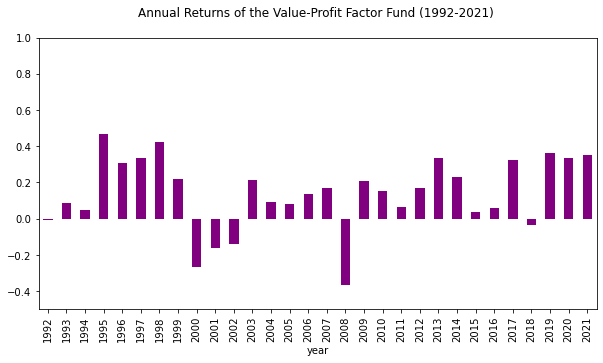

In [67]:

# Plot a bar chart for the time series
ret_fund_ann.plot(kind='bar', figsize=(10,5), x='year', color='Purple', y='ret_vw', ylim=(-0.5, 1), legend= False,\
                  title='Annual Returns of the Value-Profit Factor Fund (1992-2021) \n')

##### Step 5.2: Compare with the benchmark index using annual returns

In [59]:
# Mean, Volatility, and the Sharpe ratio
# Book Market Factor Fund
print("Average annual return of Factor Fund (%):", "{:.2f}".format(ret_fund_ann.ret_vw.mean()*100))
print("Annual volatility of Factor Fund (%) (%):", "{:.2f}".format(ret_fund_ann.ret_vw.std()*100))
print("Annual Sharpe Ratio of Factor Fund:", "{:.2f}".format(ret_fund_ann.ret_vw.mean()/ret_fund_ann.ret_vw.std()))

Average annual return of Factor Fund (%): 14.09
Annual volatility of Factor Fund (%) (%): 20.08
Annual Sharpe Ratio of Factor Fund: 0.70


In [60]:
# Benchmark Index
print("Average annual return of Benchmark Index (%):", "{:.2f}".format(ret_indx_ann.ret_vw.mean()*100))
print("Annual volatility of Benchmark Index (%) (%):", "{:.2f}".format(ret_indx_ann.ret_vw.std()*100))
print("Annual Sharpe Ratio of Benchmark Index:", "{:.2f}".format(ret_indx_ann.ret_vw.mean()/ret_indx_ann.ret_vw.std()))

Average annual return of Benchmark Index (%): 12.31
Annual volatility of Benchmark Index (%) (%): 17.44
Annual Sharpe Ratio of Benchmark Index: 0.71


In [66]:
# Past 1-year compounded returns
print("1-year compounded annual return of Factor Fund (%):",\
      "{:.2f}".format(((np.exp(ret_fund_ann[ret_fund_ann.year>=2021].logret_vw.sum())**(1/5))-1)*100))
print("1-year compounded annual return of Benchmark Index (%):",\
      "{:.2f}".format(((np.exp(ret_indx_ann[ret_indx_ann.year>=2021].logret_vw.sum())**(1/5))-1)*100))
# Past 3-year compounded returns
print("3-year compounded annual return of Factor Fund (%):",\
      "{:.2f}".format(((np.exp(ret_fund_ann[ret_fund_ann.year>=2019].logret_vw.sum())**(1/5))-1)*100))
print("3-year compounded annual return of Benchmark Index (%):",\
      "{:.2f}".format(((np.exp(ret_indx_ann[ret_indx_ann.year>=2019].logret_vw.sum())**(1/5))-1)*100))
# Past 5-year compounded returns
print("5-year compounded annual return of Factor Fund (%):",\
      "{:.2f}".format(((np.exp(ret_fund_ann[ret_fund_ann.year>=2017].logret_vw.sum())**(1/5))-1)*100))
print("5-year compounded annual return of Benchmark Index (%):",\
      "{:.2f}".format(((np.exp(ret_indx_ann[ret_indx_ann.year>=2017].logret_vw.sum())**(1/5))-1)*100))
# Past 10-year compounded returns
print("10-year compounded annual return of Factor Fund (%):",\
      "{:.2f}".format(((np.exp(ret_fund_ann[ret_fund_ann.year>=2011].logret_vw.sum())**(1/5))-1)*100))
print("10-year compounded annual return of Benchmark Index (%):",\
      "{:.2f}".format(((np.exp(ret_indx_ann[ret_indx_ann.year>=2011].logret_vw.sum())**(1/5))-1)*100))
# Compounded returns since inception (i.e., 30-year)
print("30-year compounded annual return of Factor Fund (%):",\
      "{:.2f}".format(((np.exp(ret_fund_ann.logret_vw.sum())**(1/30))-1)*100))
print("30-year compounded annual return of Benchmark Index (%):",\
      "{:.2f}".format(((np.exp(ret_indx_ann.logret_vw.sum())**(1/30))-1)*100))

1-year compounded annual return of Factor Fund (%): 6.18
1-year compounded annual return of Benchmark Index (%): 4.63
3-year compounded annual return of Factor Fund (%): 19.68
3-year compounded annual return of Benchmark Index (%): 15.37
5-year compounded annual return of Factor Fund (%): 25.66
5-year compounded annual return of Benchmark Index (%): 19.09
10-year compounded annual return of Factor Fund (%): 47.68
10-year compounded annual return of Benchmark Index (%): 37.05
30-year compounded annual return of Factor Fund (%): 12.17
30-year compounded annual return of Benchmark Index (%): 10.82


#### Step 5.3: Evaluate the monthly fund returns using factor models

In [55]:
# Read the FF3 factors from the lab session
FF3 = pd.read_csv('FF3_lab.csv')

# Merge
reg_fund = pd.merge(ret_fund, FF3, on=['year','month'])

In [56]:
# Linear regression from statsmodels
import statsmodels.formula.api as sm

# CAPM
ols_capm = sm.ols('ret_vw ~ MKT', data=reg_fund)
est_capm = ols_capm.fit()
print(est_capm.summary())

                            OLS Regression Results                            
Dep. Variable:                 ret_vw   R-squared:                       0.772
Model:                            OLS   Adj. R-squared:                  0.771
Method:                 Least Squares   F-statistic:                     1209.
Date:                Thu, 28 Apr 2022   Prob (F-statistic):          7.83e-117
Time:                        18:01:25   Log-Likelihood:                 865.07
No. Observations:                 360   AIC:                            -1726.
Df Residuals:                     358   BIC:                            -1718.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0036      0.001      3.024      0.0

In [57]:
# FF3
ols_ff3 = sm.ols('ret_vw ~ MKT+SMB+HML', data=reg_fund)
est_ff3 = ols_ff3.fit()
print(est_ff3.summary())

                            OLS Regression Results                            
Dep. Variable:                 ret_vw   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     464.7
Date:                Thu, 28 Apr 2022   Prob (F-statistic):          1.04e-122
Time:                        18:01:25   Log-Likelihood:                 885.95
No. Observations:                 360   AIC:                            -1764.
Df Residuals:                     356   BIC:                            -1748.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0041      0.001      3.667      0.0

#### Step 5.4: Top-10 fund holdings at the end of 2021

In [58]:
# End-of-2021 portfolio weights
top = sample2[['permno','MC','rank_R11']][(sample2.ryear==2021) & (sample2.rquarter==4)]

# VW
top['wt'] = top.MC/top.MC.sum()

# Merge with stock ticker
ticker = msf[(msf.year==2021) & (msf.month==12)][['permno','ticker']]
top = pd.merge(top, ticker, on=['permno'])

# Sort stocks from highest to lowest portfolio weight
top = top.sort_values('wt', ascending=False).reset_index(drop=True)
top.head(10)

,permno,MC,rank_R11,wt,ticker
0,14593,2.913284e+07,363,0.101369,AAPL
1,10107,2.525084e+07,149,0.087861,MSFT
2,93436,1.061287e+07,101,0.036928,TSLA
3,14542,9.194035e+06,99,0.031991,GOOG
4,90319,8.714586e+06,103,0.030323,GOOGL
5,13407,7.958976e+06,429,0.027694,FB
6,86580,7.352750e+06,21,0.025584,NVDA
7,92655,4.729411e+06,337,0.016456,UNH
8,47896,4.679664e+06,332,0.016283,JPM
9,66181,4.333696e+06,132,0.015079,HD


# Thank you Professor Chen we appreciate your efforts teaching us this semester.